# QFT QPE -数学原理以及代码实现
----

## 数学原理

### 1. QFT 的数学定义
设 $N=2^n$, 则 QFT 定义为
$$
\left|j\right\rangle \to \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i jk/N} \left|k\right\rangle
$$
因此 QFT 的矩阵为
$$
(F_N)_{kj} = \frac{1}{\sqrt{N}}e^{2\pi i jk/N}
$$
对于一般的量子态
$$
\left|\psi\right\rangle=\sum_{j=0}^{N-1} a_j \left|j\right\rangle
$$
经过 QFT 后
$$
\left|\tilde{\psi}\right\rangle = F_N \left|\psi\right\rangle
$$
其中
$$
\tilde{a}_k=\frac{1}{\sqrt{N}}\sum_{j=0}^{N-1} a_j e^{2\pi i jk/N}
$$
所以可以理解为: `QFT = 对量子态的振幅做归一化的 DFT`

### 2. 为什么 QFT 是 unitary 的？
因为量子门必须满足
$$
U^\dagger U = I
$$
QFT 中的 $\frac{1}{\sqrt{N}}$ 是为了保证
$$
F_N^\dagger F_N = I
$$
因此
$$
F_N^{-1}=F_N^\dagger
$$
这就是 IQFT:
$$
\left|k\right\rangle \to \frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}e^{-2\pi ijk/N}\left|j\right\rangle
$$

### 3. QFT 与 Phase 的关系
假设
$$
\phi=\frac{m}{M}
$$
构造状态
$$
\left|\Phi_\phi\right\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}e^{2\pi i k \phi}\left|k\right\rangle
$$
所以
$$
\left|\Phi_\phi\right\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}e^{2\pi i k m/M}\left|k\right\rangle
$$
这正好是
$$
F_N\left|m\right\rangle
$$
因此有
$$
F_N^\dagger\left|\Phi_\phi\right\rangle = \left|m\right\rangle
$$

### 4. 数值实例
下面统一使用 $\phi=\frac{1}{8}$. 取 $d=4$ 个 phase qubit, 所以 $N=2^4=16$. 因为
$$
\phi=\frac{1}{8}=\frac{2}{16}
$$
有
$$
m=2,\quad \Rightarrow \quad m=(0010)_2
$$
若能构造
$$
\left|\Phi_{1/8}\right\rangle = \frac{1}{4}\sum_{k=0}^{15} e^{2\pi i k/8} \left|k\right\rangle
$$
则
$$
IQFT\left|\Phi_{1/8}\right\rangle = \left|0010\right\rangle
$$
这就是后面的 QPE 应该输出的结果.

## 代码实现

[QFT]: Starting Quantum Fourier Transform Algorithm
[QFT]: Input parameters: 
        - Number of qubits = 4
        - Initial state = [ 2.50000000e-01+0.00000000e+00j  1.76776695e-01+1.76776695e-01j
  1.53080850e-17+2.50000000e-01j -1.76776695e-01+1.76776695e-01j
 -2.50000000e-01+3.06161700e-17j -1.76776695e-01-1.76776695e-01j
 -4.59242550e-17-2.50000000e-01j  1.76776695e-01-1.76776695e-01j
  2.50000000e-01-6.12323400e-17j  1.76776695e-01+1.76776695e-01j
  7.65404249e-17+2.50000000e-01j -1.76776695e-01+1.76776695e-01j
 -2.50000000e-01+9.18485099e-17j -1.76776695e-01-1.76776695e-01j
 -1.07156595e-16-2.50000000e-01j  1.76776695e-01-1.76776695e-01j]
        - Inverse = True
[QFT]: Stage 1: Constructing QFT circuit for 4 qubits (inverse=True)
[QFT]:   Constructed inverse QFT circuit
[QFT]: Stage 2: Performing quantum simulation
[QFT]:   Set initial state vector (normalized): [ 2.50000000e-01+0.00000000e+00j  1.76776695e-01+1.76776695e-01j
  1.53080850e-17+2.50000000e-01j -1.76776695e-01+1

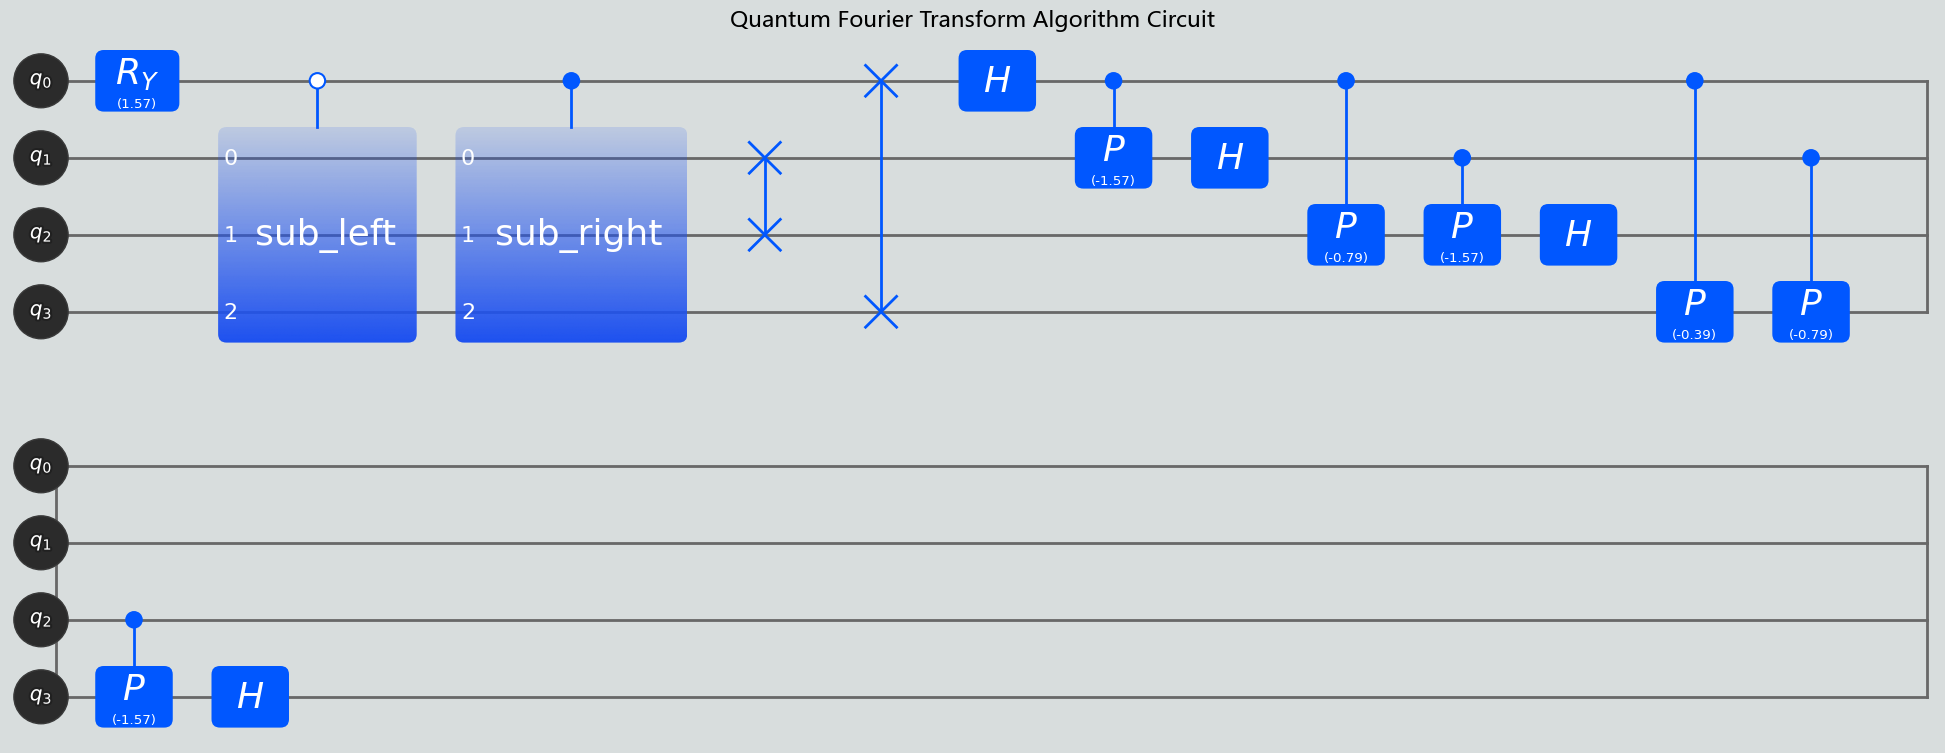

In [1]:
# 先绘制 QFT 的线路图
import numpy as np
from unitarylab_algorithms import QFTAlgorithm

d = 4
N = 2**d
phi = 1 / 8

k = np.arange(N)
phase_state = np.exp(2j * np.pi * phi * k) / np.sqrt(N)

%matplotlib inline
qft_algorithm = QFTAlgorithm(text_mode="plain")
iqft_result = qft_algorithm.run(
    n=d,
    state=phase_state,
    inverse=True,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [2]:
# 手写模拟 QFT / IQFT
j = np.arange(N)
k = np.arange(N)

F = np.exp(2j * np.pi * np.outer(j, k) / N) / np.sqrt(N)

# 验证 QFT 是否为酉矩阵
unitary_error = np.linalg.norm(F.conj().T @ F - np.eye(N))
print(f"unitary error: {unitary_error}")

phase_state = np.exp(2j * np.pi * k * phi) / np.sqrt(N)
manual_iqft_state = F.conj().T @ phase_state  # 执行IQFT
manual_iqft_probabilities = np.abs(manual_iqft_state) ** 2  # 计算概率

# 找出概率最大的结果
best_index = np.argmax(manual_iqft_probabilities)
best_bits = format(best_index, f"0{d}b")

print("Decoded bits =", best_bits)

unitary error: 9.03831772436102e-15
Decoded bits = 0010


## 数学原理

### 1. QPE 所解决问题
给定一个 unitary 矩阵 $U$, 以及它的某个本征态 $\left|\psi\right\rangle$, 满足
$$
U\left|\psi\right\rangle = e^{2\pi i\phi}\left|\psi\right\rangle,\quad \phi \in [0,1)
$$
QPE 的目标就是通过测量得到 $\phi$.

### 2. QPE 所使用的寄存器
- Phase register: 有 $d$ 个qubits, $\left|0^d\right\rangle$, 负责储存待求解的 phase.
- Target register: 准备成 $\left|\psi\right\rangle$
整个初态为
$$
\left|0^d\right\rangle \left|\psi\right\rangle
$$

### 3. 执行流程
#### 第一步: 应用 Hadamard 门, 使其变为均匀叠加态
对 phase register 应用 Hadamard 门, 得到
$$
\frac{1}{\sqrt{2^d}}\sum_{k=0}^{2^d-1}\left|k\right\rangle\left|\psi\right\rangle
$$
设 $M=2^d$, 则
$$
\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1}\left|k\right\rangle\left|\psi\right\rangle
$$

#### 第二步: 受控 U 门
现在执行受控 U 门
$$
U^{2^0}, U^{2^1}, U^{2^2}, \cdots, U^{2^{d-1}}
$$
因为有
$$
U^{2^j}\left|\psi\right\rangle=e^{2\pi i 2^j \phi}\left|\psi\right\rangle
$$

#### 第三步: 总演化
所有的受控U 门执行完毕之后, 得到
$$
\left(\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1}e^{2\pi i k \phi}\left|k\right\rangle\right) \otimes \left|\psi\right\rangle
$$
括号中内容就是 QFT 的
$$
\left|\Phi_\phi\right\rangle
$$

因此整个 QPE :
$$
\phi \to \frac{1}{\sqrt{M}}\sum_k e^{2\pi i k \phi}\left|k\right\rangle \to IQFT \to \left|\tilde \phi\right\rangle
$$

### 4. 数值实例
选用 T 门进行模拟:
$$
T = \begin{bmatrix}
1 & 0 \\ 
0 & e^{i\pi/4}
\end{bmatrix}
$$
有
$$
e^{i\pi/4}=e^{2\pi i/8}\Rightarrow \phi=\frac{1}{8}
$$
对于本征态 $\left|1\right\rangle$ 满足
$$
T\left|1\right\rangle=e^{2\pi i /8}\left|1\right\rangle
$$

取 $d=4$, 有
$$
\phi=\frac{1}{8}=\frac{2}{16}
$$
结果应该输出 $m=2$, 即
$$
0010
$$

## 代码实现

[QPE]: Starting Quantum Phase Estimation Algorithm
[QPE]: Input parameters: 
        - Unitary operator = T
        - Precision bits = 4
[QPE]: Stage 1: Validating and parsing parameters
[QPE]:   Phase register: 4 Qubits
[QPE]:   Target register: 1 Qubits
[QPE]:   Total qubits: 5
[QPE]:   Theoretical phase resolution: 1/16 ≈ 0.062500
[QPE]: Stage 2: Building QPE core circuit
[QPE]:   Built controlled U operator sequence
[QPE]:   Connected IQFT module
[QPE]: Stage 3: Executing quantum simulation
[QPE]:   Underlying simulation computation time: 0.0010 seconds
[QPE]: Stage 4: Executing classical post-processing
[QPE]:   Optimal phase bit string: |0010> (probability: 1.0000)
[QPE]:   Equivalent decimal estimated phase: 0.125000
[QPE]: Stage 5: Exporting circuit diagram
[QPE]: Output information: 
        - Estimated phase = 0.125
        - Best phase bit string = 0010
        - Best phase probability = 1.0
        - Computation time (s) = 0.0010063648223876953
        - Phase probabilities

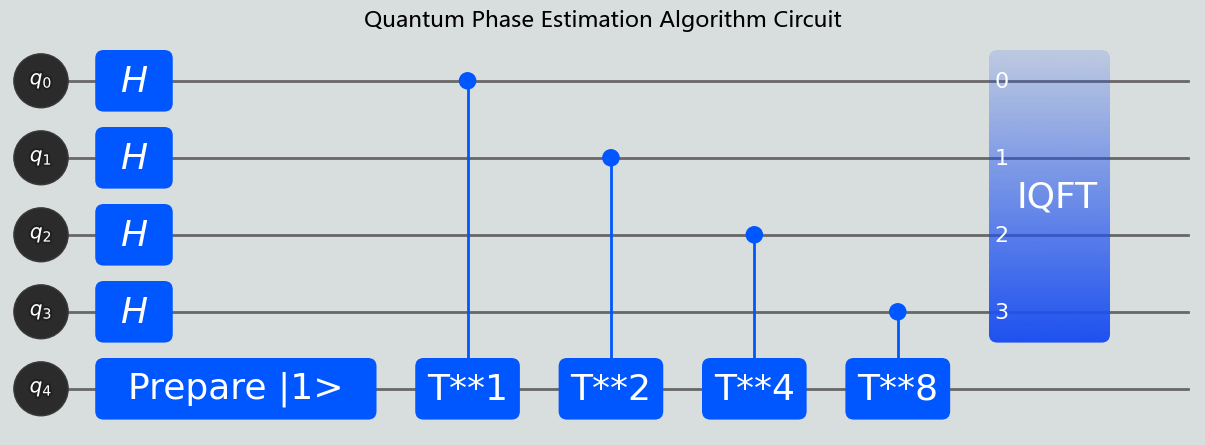

In [3]:
from unitarylab import Circuit
from unitarylab_algorithms import QPEAlgorithm

# 构造 T 门
U = Circuit(1, name="T")
U.t(0)

# 制备本征态
prepare_target = Circuit(1, name="Prepare |1>")
prepare_target.x(0)

# 运行官方求解
qpe = QPEAlgorithm(text_mode="Plain")
qpe_result = qpe.run(
    U=U,
    d=4,
    prepare_target=prepare_target,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)


In [4]:
# Numpy 手写 QPE
d = 4
M = 2**d
phi = 1 / 8
k = np.arange(M)

# 构造初态
phase_state = np.exp(2j * np.pi * phi * k) / np.sqrt(M)

# 实现 IQFT
j = np.arange(M)
k = np.arange(M)

F = np.exp(2j * np.pi * np.outer(k, j) / M) / np.sqrt(M)

# 进行 IQFT
manual_qpe_state = F.conj().T @ phase_state
manual_probabilities = np.abs(manual_qpe_state) ** 2

# 找到估计值
manual_index = np.argmax(manual_probabilities)

manual_bits = format(
    manual_index,
    f"0{d}b",
)
manual_phase = manual_index / M

print("Manual bits =", manual_bits)
print("Manual phase =", manual_phase)

Manual bits = 0010
Manual phase = 0.125


In [5]:
# 官方结果
official_phase = qpe_result["Estimated phase"]
official_bits = qpe_result["Best phase bit string"]
official_probability = qpe_result["Best phase probability"]

print("Official bits =", official_bits)
print("Official phase =", official_phase)
print("Best probability =", official_probability)

Official bits = 0010
Official phase = 0.125
Best probability = 1.0


In [6]:
# 对比
print("\n========== QPE Comparison ==========")
print("Theory   =", phi)
print("Manual   =", manual_phase)
print("Official =", official_phase)
print("Manual bts   =", manual_bits)
print("Official bits =", official_bits)

# 误差
manual_error = abs(manual_phase - phi)
official_error = abs(official_phase - phi)

print("\n========== QPE Error==========")
print("Manual error =", manual_error)
print("Official error =", official_error)


========== QPE Comparison ==========
Theory   = 0.125
Manual   = 0.125
Official = 0.125
Manual bts   = 0010
Official bits = 0010

========== QPE Error==========
Manual error = 0.0
Official error = 0.0


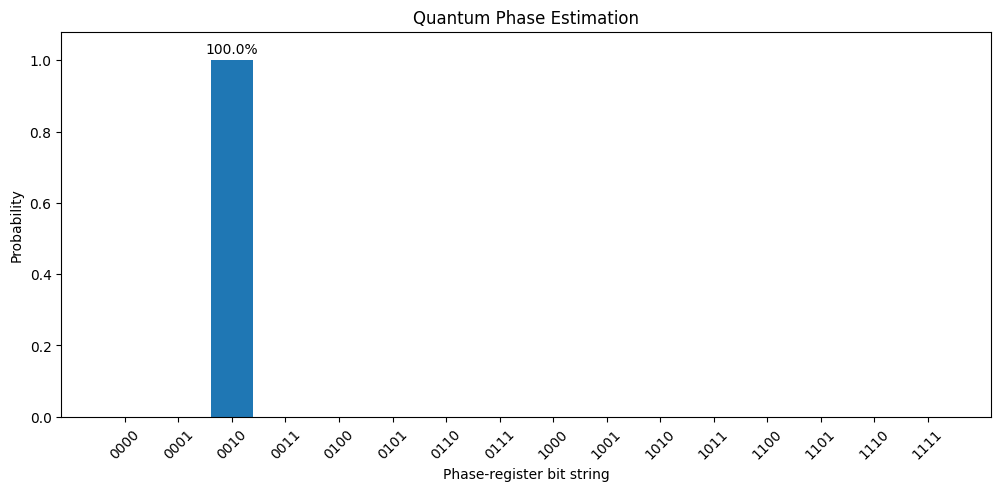

In [7]:
# 绘制 QPE 相位概率图
import matplotlib.pyplot as plt

%matplotlib inline

phase_bits = [
    format(
        i,
        f"0{d}b",
    )
    for i in range(M)
]

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    phase_bits,
    manual_probabilities,
)

ax.bar_label(
    bars,
    labels=[(f"{p * 100:.1f}%" if p > 1e-6 else "") for p in manual_probabilities],
    padding=3,
)

ax.set_xlabel("Phase-register bit string")
ax.set_ylabel("Probability")
ax.set_title("Quantum Phase Estimation")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.set_ylim(
    0,
    1.08,
)

plt.show()

### 后续问题: 若 phase 不能被精确表示
若 $\phi=0.14$, 而 $d=4$, 则精度为
$$
\frac{1}{16}=0.0625
$$
可能的输出只能是
$$
0, \frac{1}{16}, \frac{2}{16}, \cdots
$$
于是 $\phi=0.14$ 不能精确表示. 但是 QPE 会产生一个概率分布, 峰值集中最接近的几个节点附近. 所以
$$
d\Rightarrow \Delta \phi \sim 2^{-d}
$$
使用 $d$ 个 phase qubits 时, 相位估计的分辨率为 $1/2^{d}$.